# Evaluation Charts

Renders per-metric comparison charts (Pandas vs Polars vs PyArrow) from the CSVs produced by `optimize_pipeline.ipynb`:
- `performance_before.csv` — Pandas-only baseline
- `performance_after.csv` — all three libraries

In [ ]:
!pip install matplotlib pandas numpy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [2]:
before_df = pd.read_csv("performance_before.csv")
after_df  = pd.read_csv("performance_after.csv")
print("before:", before_df.shape, "| after:", after_df.shape)
after_df.head()

before: (24, 8) | after: (72, 8)


,operation,library,run,execution_time_sec,cpu_initial_percent,cpu_final_percent,memory_used_mb,throughput_rows_per_sec
0,Filter High Discount Books,Pandas,1,0.035973,24.10,18.10,67.279,4101921.0
1,Filter High Discount Books,Pandas,2,0.024698,20.00,11.40,67.279,5974589.0
2,Filter High Discount Books,Pandas,3,0.023769,16.40,10.80,67.279,6207976.0
3,Filter High Discount Books,Pandas,average,0.028147,20.17,13.43,67.279,5242493.0
4,GroupBy Publisher Aggregation,Pandas,1,0.020558,15.70,10.10,0.459,7177748.0


## Per-Metric Comparison Across All Operations (Pandas vs Polars vs PyArrow)

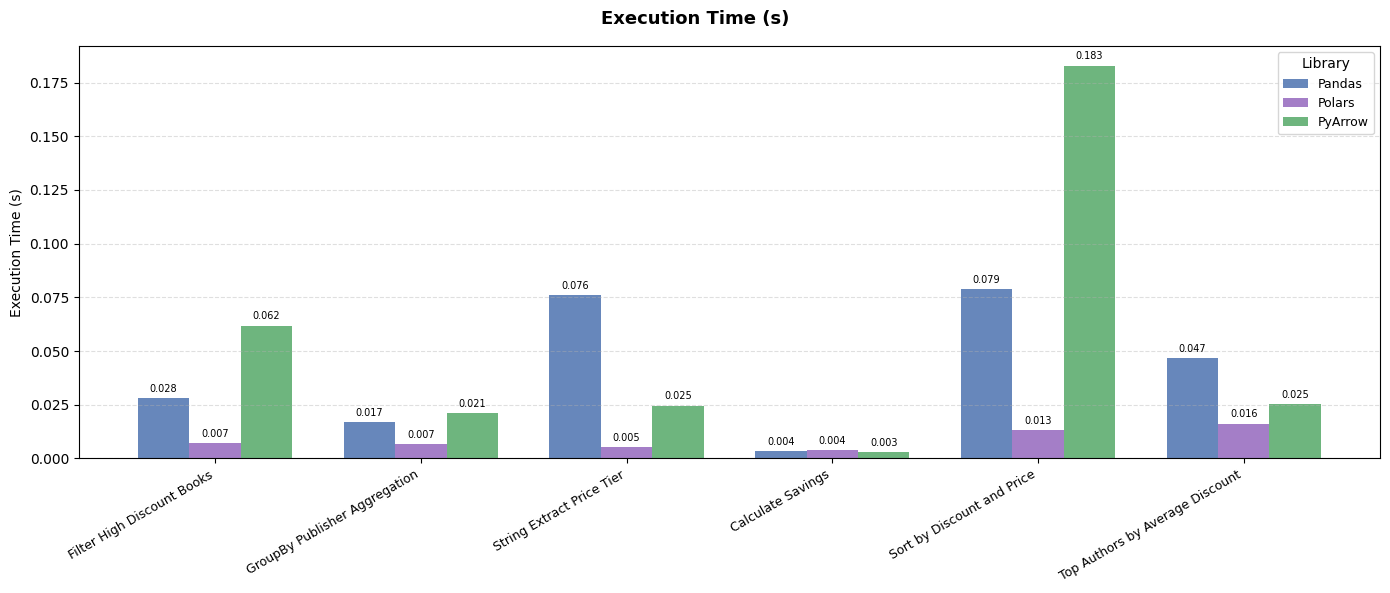

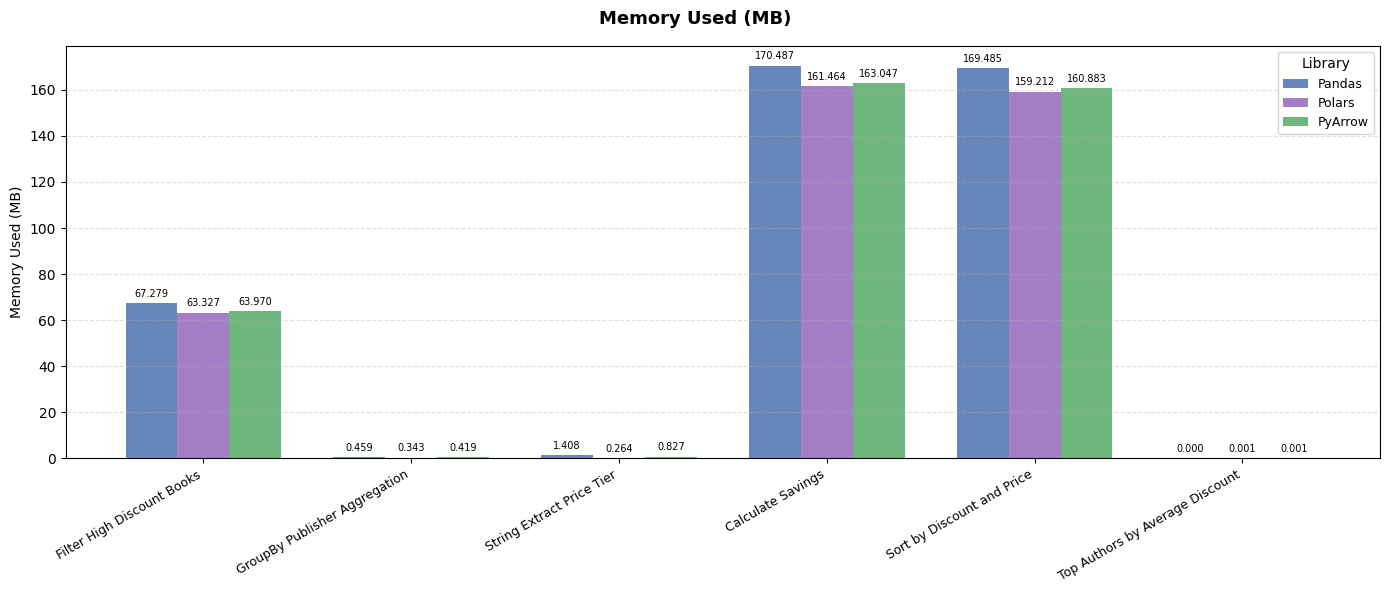

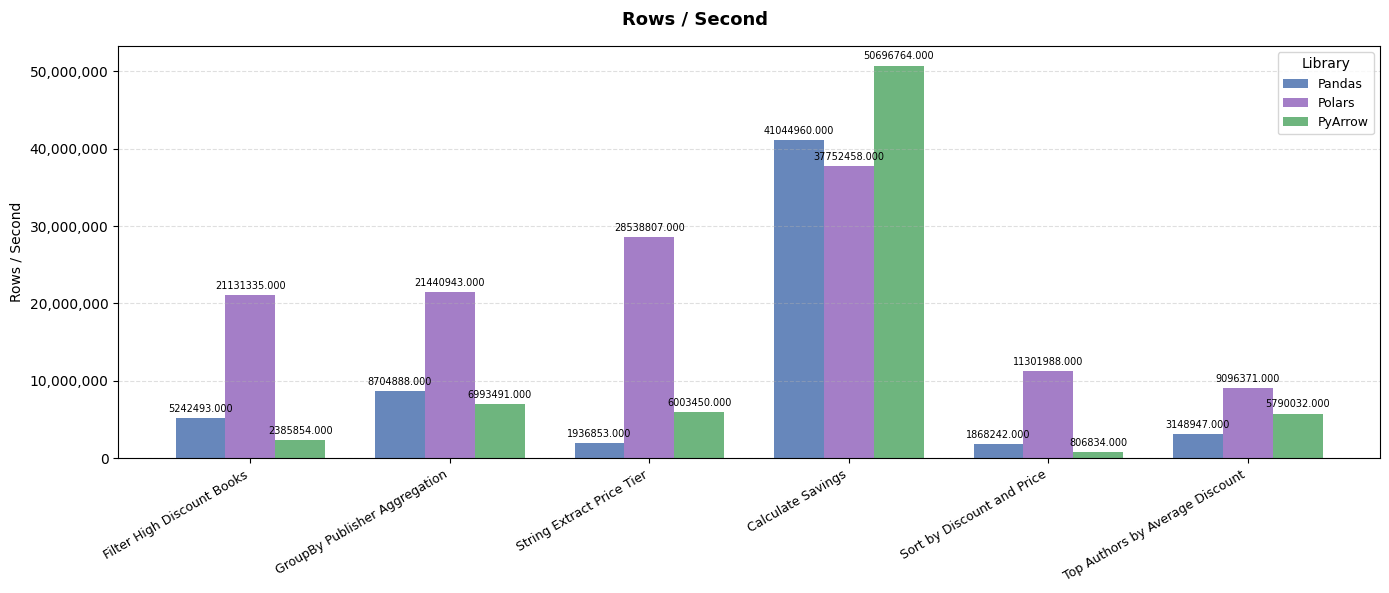

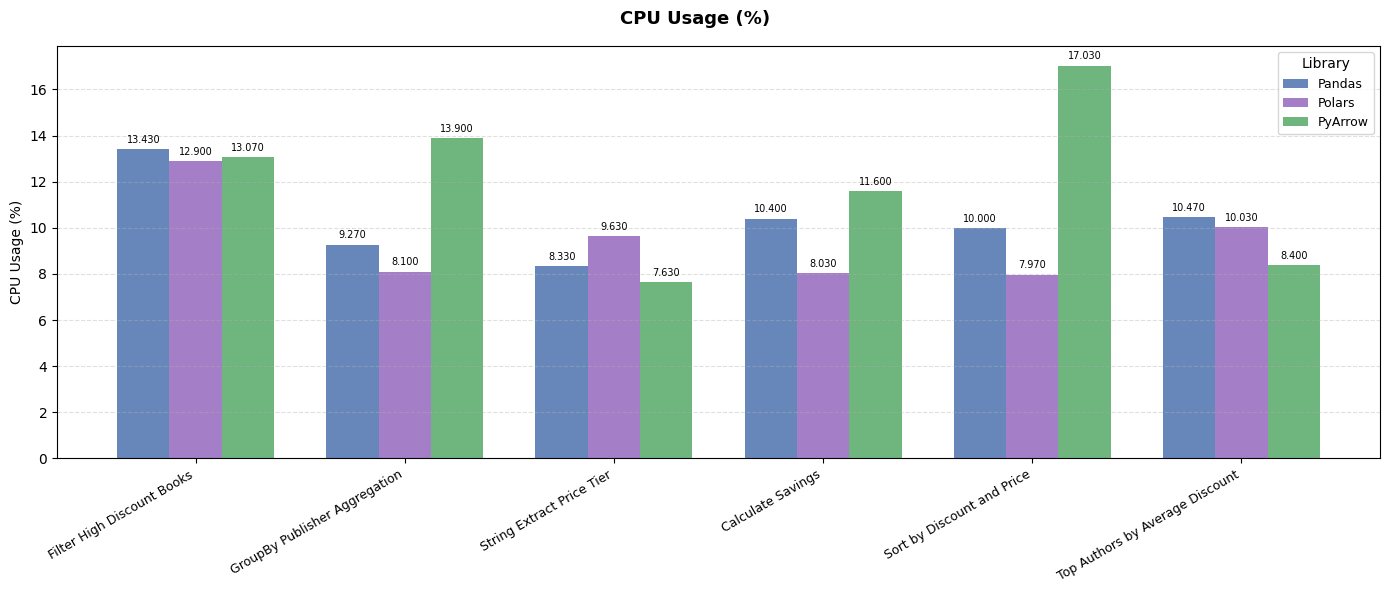

In [3]:
LIBRARIES = ["Pandas", "Polars", "PyArrow"]
COLORS    = ["#4C72B0", "#9467BD", "#55A868"]  # blue, purple, green
METRICS   = [
    ("execution_time_sec",      "Execution Time (s)"),
    ("memory_used_mb",          "Memory Used (MB)"),
    ("throughput_rows_per_sec", "Rows / Second"),
    ("cpu_final_percent",       "CPU Usage (%)"),
]

avg_df     = after_df[after_df["run"] == "average"].copy()
operations = avg_df["operation"].unique().tolist()

x     = np.arange(len(operations))  # 6 tick positions
width = 0.25                         # width of each individual bar

for metric, title in METRICS:
    fig, ax = plt.subplots(figsize=(14, 6))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    for i, (lib, color) in enumerate(zip(LIBRARIES, COLORS)):
        vals = [
            avg_df.loc[
                (avg_df["operation"] == op) & (avg_df["library"] == lib), metric
            ].values[0]
            if ((avg_df["operation"] == op) & (avg_df["library"] == lib)).any() else 0
            for op in operations
        ]
        offset = (i - 1) * width  # -0.25, 0.0, +0.25 relative to each tick
        bars = ax.bar(x + offset, vals, width, label=lib, color=color, alpha=0.85)
        ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels(operations, rotation=30, ha="right", fontsize=9)
    ax.set_ylabel(title, fontsize=10)
    ax.legend(title="Library", fontsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    if metric == "throughput_rows_per_sec":
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda v, _: f"{v:,.0f}")
        )

    plt.tight_layout()
    plt.show()